# Notebook 03: Exploratory Data Analysis (EDA)

**Dataset:** US House Prices — 10 States (Cleaned)  
**Goal:** Understand distributions, trends, and outliers in the cleaned dataset before statistical modelling.

---

## 1. Setup & Data Loading

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14

# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_house_data.csv', parse_dates=['date'])

print(f'Shape: {df.shape}')
df.head()

Shape: (11410, 10)


,date,bed,bath,price,broker,street,city,state_name,zip_code,house_sqft
0,2024-08-29,4.0,4.0,415000.0,Unknown,2004 W 23rd Ct,Panama City,Florida,32405,2520.0
1,2024-08-29,2.0,2.0,58000.0,Unknown,5390 Webb St,Graceville,Florida,32440,704.0
2,2024-08-29,3.0,3.0,375000.0,Coldwell Banker Hartung,6761 Landover Cir,Tallahassee,Florida,32317,1926.0
3,2024-08-29,0.0,0.0,190000.0,"EXP Realty, LLC",1701 S Fairfield Dr,Perdido Key,Florida,32507,1132.0
4,2024-08-29,3.0,3.0,233900.0,"D R Horton Realty of NW Florida, LLC",6274 June Bug Dr,Milton,Florida,32583,1205.0


## 2. Dataset Overview

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11410 entries, 0 to 11409
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        11410 non-null  datetime64[ns]
 1   bed         11410 non-null  float64       
 2   bath        11410 non-null  float64       
 3   price       11410 non-null  float64       
 4   broker      11410 non-null  object        
 5   street      11410 non-null  object        
 6   city        11410 non-null  object        
 7   state_name  11410 non-null  object        
 8   zip_code    11410 non-null  int64         
 9   house_sqft  11410 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(4)
memory usage: 891.5+ KB


In [34]:
df.describe()

,date,bed,bath,price,zip_code,house_sqft
count,11410,11410.000000,11410.000000,1.141000e+04,11410.000000,11410.000000
mean,2024-08-28 07:19:04.049079552,3.231989,3.231989,7.034579e+05,60773.255127,1977.884075
min,2024-08-16 00:00:00,0.000000,0.000000,1.000000e+00,10002.000000,1.000000
25%,2024-08-28 00:00:00,3.000000,3.000000,3.070000e+05,29928.000000,1339.000000
50%,2024-08-29 00:00:00,3.000000,3.000000,4.800000e+05,62656.000000,1740.000000
75%,2024-08-30 00:00:00,4.000000,4.000000,7.650000e+05,92253.000000,2322.000000
max,2024-09-01 00:00:00,21.000000,21.000000,1.780000e+08,99403.000000,247000.000000
std,NaN,1.137298,1.137298,2.883136e+06,30490.711413,3066.374216


In [35]:
# Missing values check
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'None — dataset is complete.')

Missing values per column:
None — dataset is complete.


In [36]:
# Records per state
state_counts = df['state_name'].value_counts()
print('Listings per state:')
print(state_counts)

Listings per state:
state_name
California        2746
Arizona           1025
New York          1009
Florida            996
Illinois           965
Louisiana          951
Washington         950
North Carolina     945
Alabama            919
South Carolina     904
Name: count, dtype: int64


## 3. Univariate Analysis

### 3.1 Price Distribution

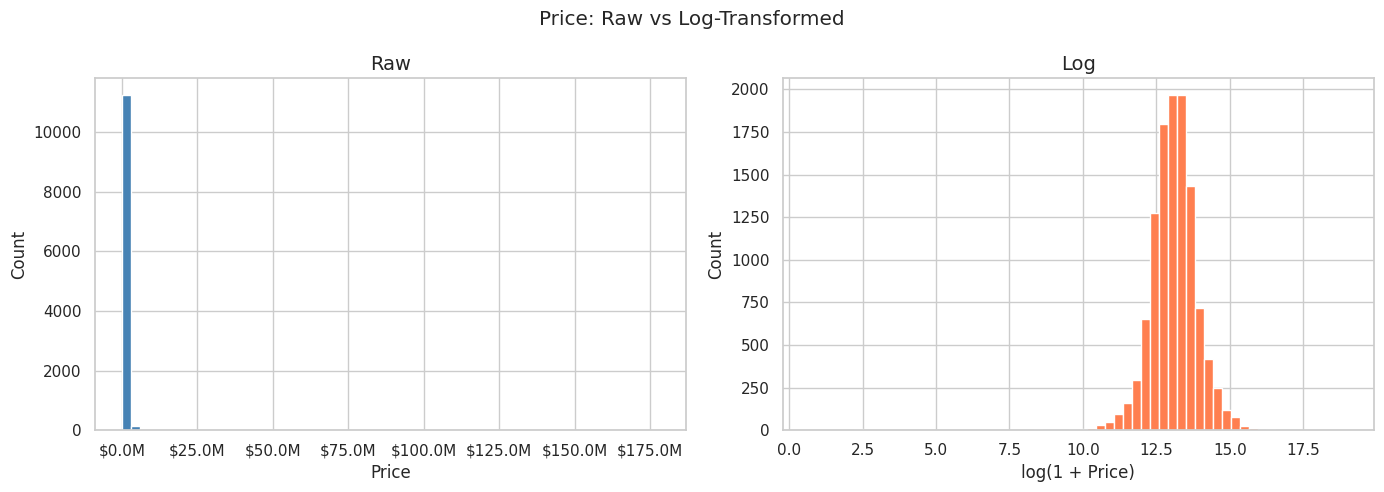

Skew (raw): 55.762
Skew (log): -2.583
Median price: $480,000
Mean price: $703,458


In [37]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

price = df['price']
log_price = np.log1p(price)

# Raw
ax[0].hist(price, bins=60, color='steelblue', edgecolor='white')
ax[0].set(title='Raw', xlabel='Price', ylabel='Count')
ax[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
)

# Log
ax[1].hist(log_price, bins=60, color='coral', edgecolor='white')
ax[1].set(title='Log', xlabel='log(1 + Price)', ylabel='Count')

plt.suptitle('Price: Raw vs Log-Transformed')
plt.tight_layout()
plt.show()

print("Skew (raw):", round(price.skew(), 3))
print("Skew (log):", round(log_price.skew(), 3))
print("Median price:", f"${price.median():,.0f}")
print("Mean price:", f"${price.mean():,.0f}")

### 3.2 House Size (sqft) Distribution

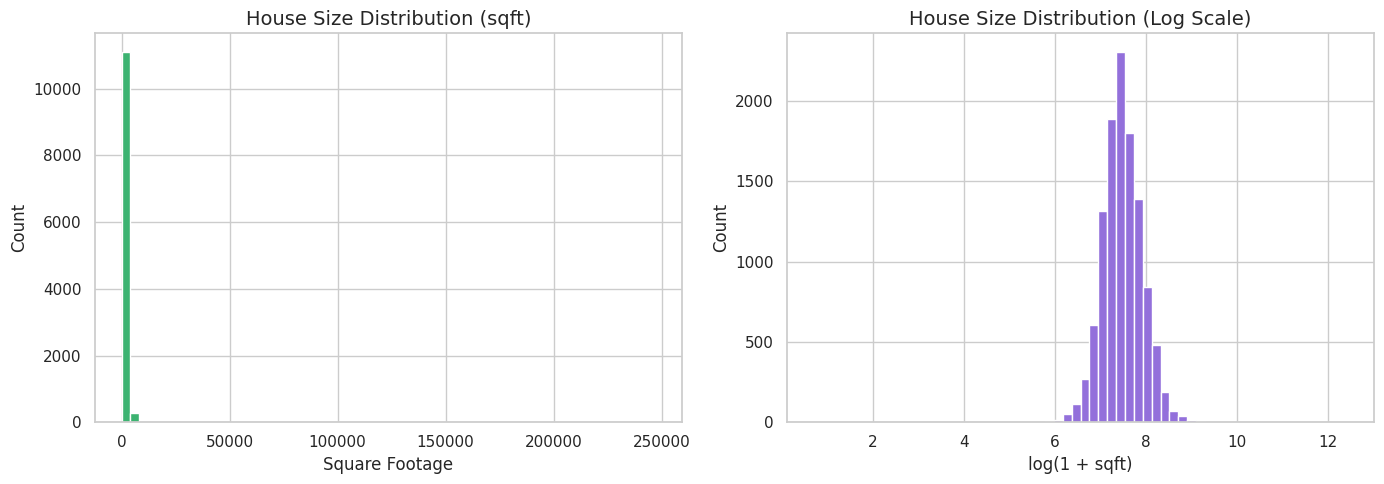

Mean sqft:   1,978
Median sqft: 1,740
Skewness:    66.353


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['house_sqft'], bins=60, edgecolor='white', color='mediumseagreen')
axes[0].set_title('House Size Distribution (sqft)')
axes[0].set_xlabel('Square Footage')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['house_sqft']), bins=60, edgecolor='white', color='mediumpurple')
axes[1].set_title('House Size Distribution (Log Scale)')
axes[1].set_xlabel('log(1 + sqft)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Mean sqft:   {df['house_sqft'].mean():,.0f}")
print(f"Median sqft: {df['house_sqft'].median():,.0f}")
print(f"Skewness:    {df['house_sqft'].skew():.3f}")

### 3.3 Bedrooms & Bathrooms Distribution

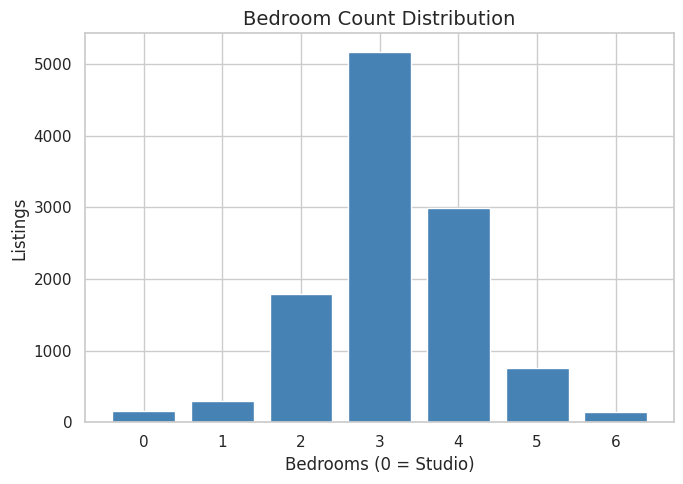

In [39]:
fig, ax = plt.subplots(figsize=(7, 5))

bed_counts = df['bed'].value_counts().sort_index()

# Keep common range (0–6)
# Most properties fall within 0–6 bedrooms; higher values are rare outliers
# and including them would clutter the x-axis without adding useful insight
bed_counts = bed_counts[bed_counts.index <= 6]

ax.bar(bed_counts.index, bed_counts.values, color='steelblue', edgecolor='white')

ax.set_title('Bedroom Count Distribution')
ax.set_xlabel('Bedrooms (0 = Studio)')
ax.set_ylabel('Listings')
ax.set_xticks(bed_counts.index)

plt.tight_layout()
plt.show()

## 4. Bivariate Analysis

### 4.1 Price vs. House Size

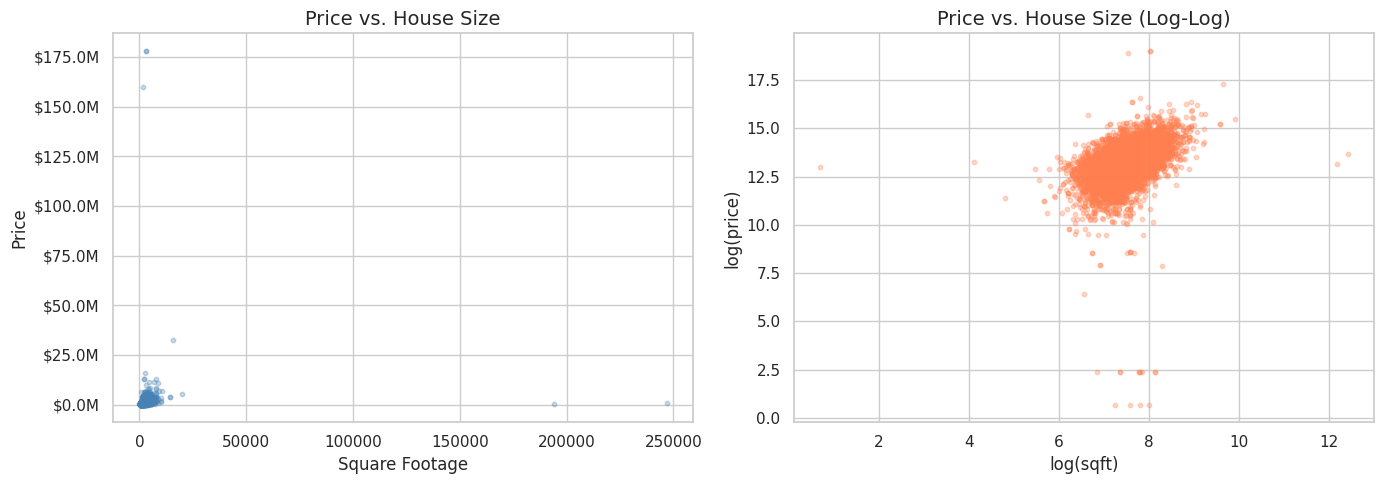

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['house_sqft'], df['price'], alpha=0.3, s=10, color='steelblue')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].set_title('Price vs. House Size')
axes[0].set_xlabel('Square Footage')
axes[0].set_ylabel('Price')

# Log-log
axes[1].scatter(np.log1p(df['house_sqft']), np.log1p(df['price']), alpha=0.3, s=10, color='coral')
axes[1].set_title('Price vs. House Size (Log-Log)')
axes[1].set_xlabel('log(sqft)')
axes[1].set_ylabel('log(price)')

plt.tight_layout()
plt.show()


### 4.2 Price vs. Bedrooms & Bathrooms

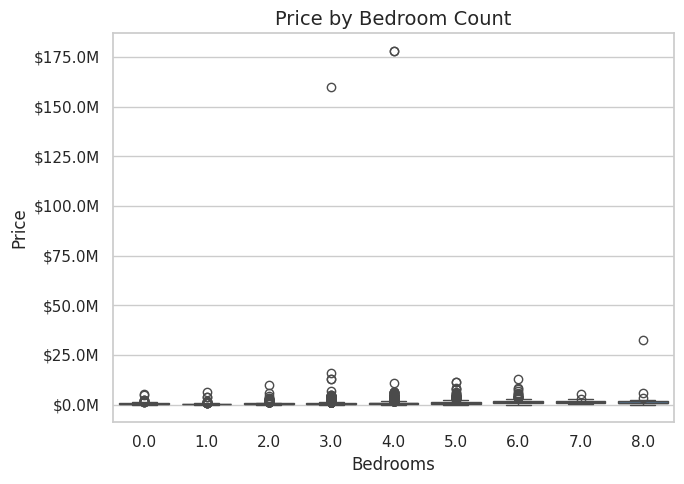

In [41]:
fig, axes = plt.subplots(figsize=(7, 5))

sns.boxplot(data=df[df['bed'] <= 8], x='bed', y='price', ax=axes, color='steelblue' )
axes.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes.set_title('Price by Bedroom Count')
axes.set_xlabel('Bedrooms')
axes.set_ylabel('Price')

plt.tight_layout()
plt.show()



## 5. Geographic Analysis

### 5.1 Median Price by State

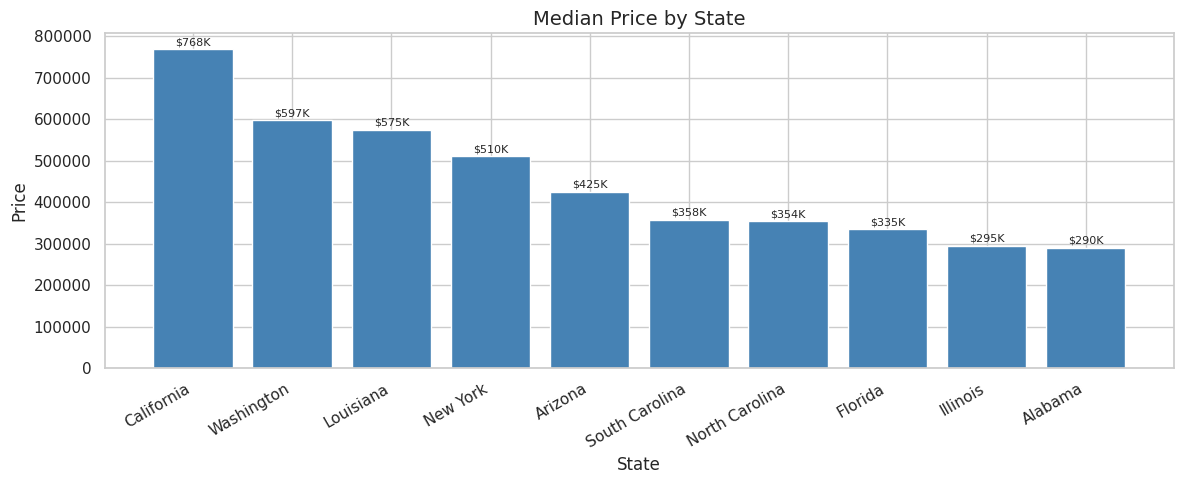

In [42]:
state_price = df.groupby('state_name')['price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(state_price.index, state_price.values, color='steelblue')

ax.set_title('Median Price by State')
ax.set_xlabel('State')
ax.set_ylabel('Price')

plt.xticks(rotation=30, ha='right')

for bar, val in zip(bars, state_price.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'${val/1e3:.0f}K', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### 5.2 Price Distribution by State (Box Plot)

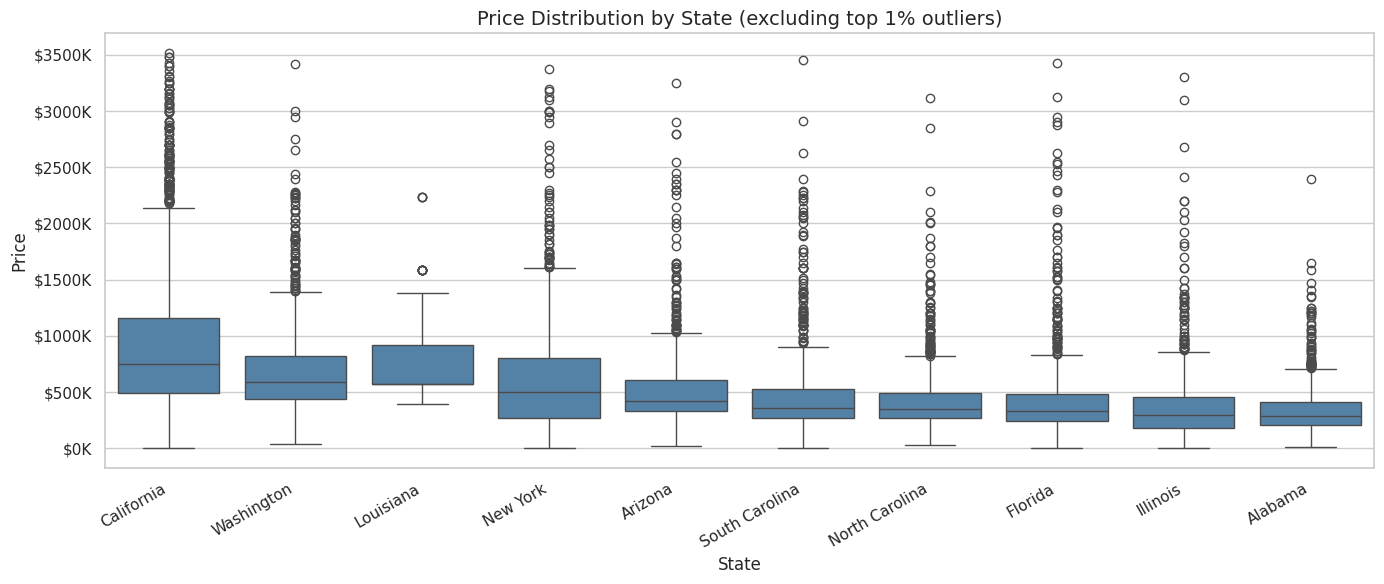

In [43]:
state_order = df.groupby('state_name')['price'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=df[df['price'] < df['price'].quantile(0.99)],  # Remove extreme outliers for readability
    x='state_name',
    y='price',
    order=state_order,
    color='steelblue',
    ax=ax
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_title('Price Distribution by State (excluding top 1% outliers)', fontsize=14)
ax.set_xlabel('State')
ax.set_ylabel('Price')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 5.3 Listings Count by State

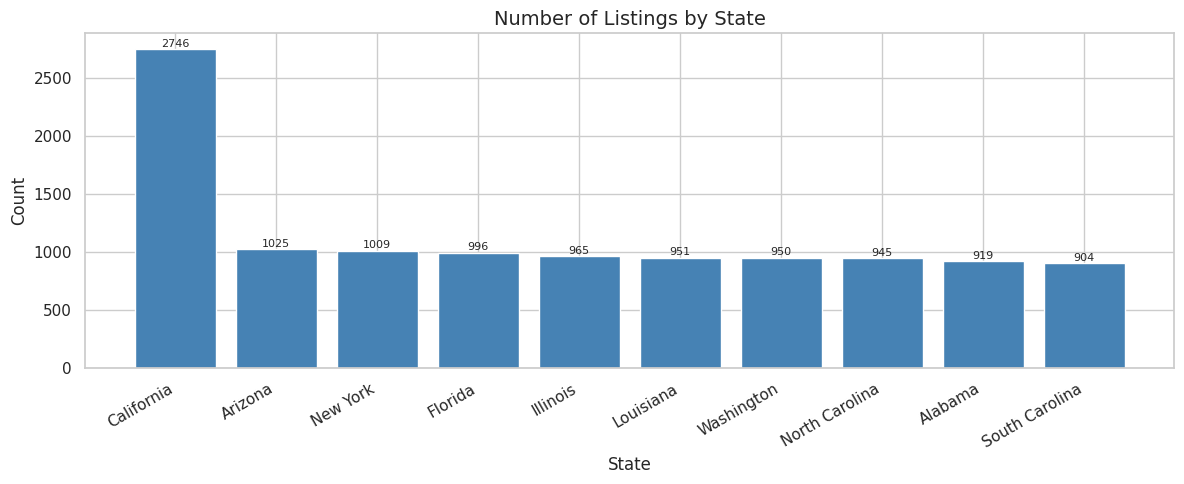

In [44]:
listing_counts = df['state_name'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(listing_counts.index, listing_counts.values, color='steelblue', edgecolor='white')

ax.set_title('Number of Listings by State')
ax.set_xlabel('State')
ax.set_ylabel('Count')

plt.xticks(rotation=30, ha='right')

# Add value labels
for bar, val in zip(bars, listing_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{val}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()

## 6. Temporal Trends

### 6.1 Daily Listing Volume

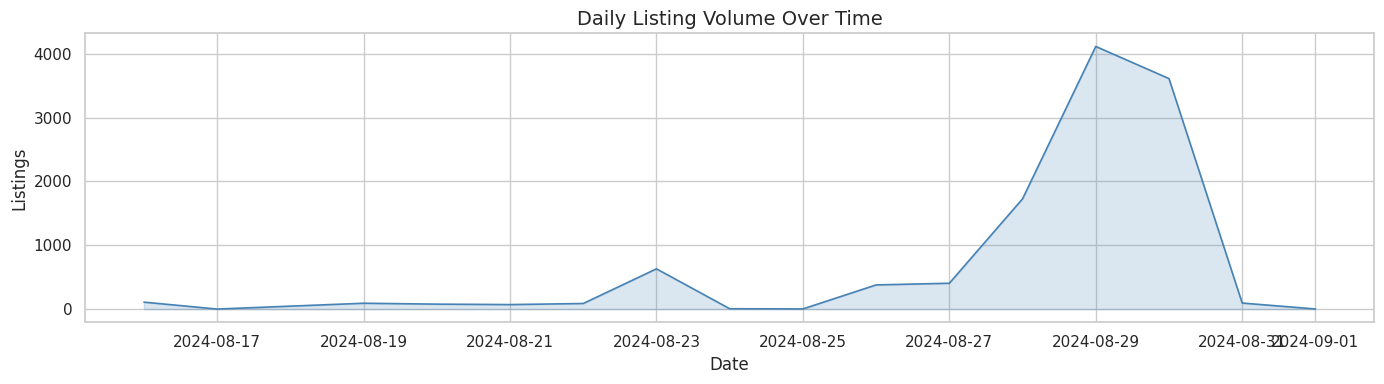

In [45]:
daily_listings = df.groupby('date').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_listings['date'], daily_listings['count'], color='steelblue', linewidth=1.2)
ax.fill_between(daily_listings['date'], daily_listings['count'], alpha=0.2, color='steelblue')
ax.set_title('Daily Listing Volume Over Time', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Listings')
plt.tight_layout()
plt.show()

Although temporal aggregation was attempted by grouping listings by date, the resulting distribution showed irregular spikes and inconsistencies. This suggests that the date feature does not represent a reliable time series signal (possibly due to batch uploads or data collection artifacts). Therefore, it was excluded from further analysis.


### 6.2 Median Price Over Time (7-day Rolling Average)

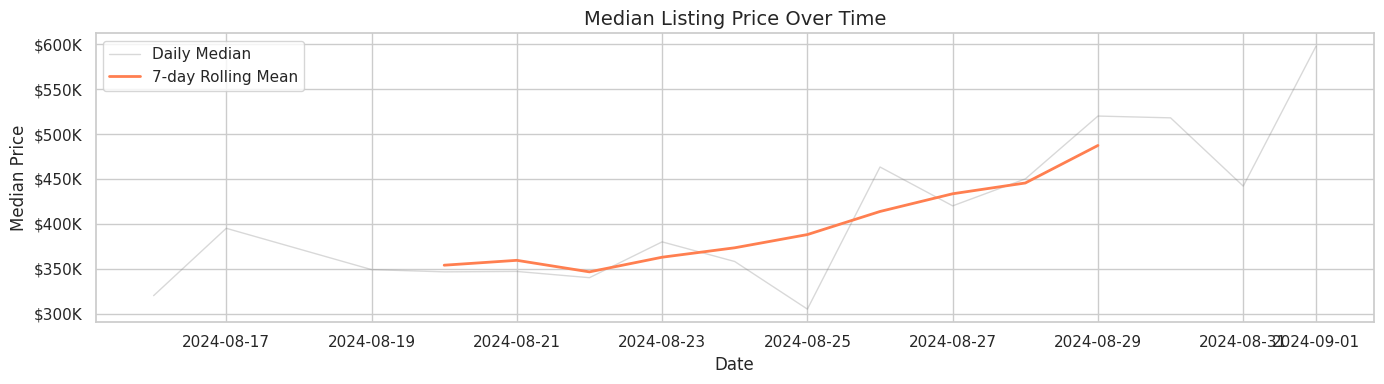

In [46]:
daily_price = df.groupby('date')['price'].median().reset_index()
daily_price['rolling_7d'] = daily_price['price'].rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_price['date'], daily_price['price'], alpha=0.3, color='grey', linewidth=1, label='Daily Median')
ax.plot(daily_price['date'], daily_price['rolling_7d'], color='coral', linewidth=2, label='7-day Rolling Mean')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_title('Median Listing Price Over Time', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Median Price')
ax.legend()
plt.tight_layout()
plt.show()

A slight upward trend in median listing prices is observed; however, given irregularities in listing volume and potential data collection artifacts, this trend should be interpreted cautiously.

### 6.3 Monthly Listing Trends by State

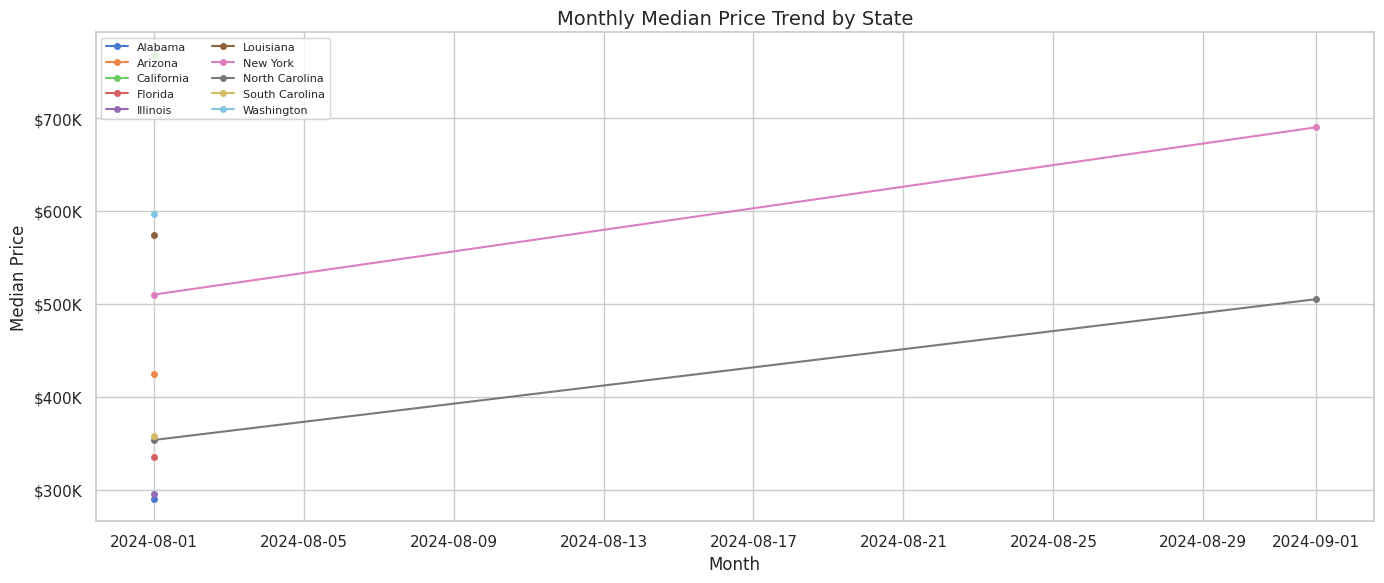

In [47]:
df['month'] = df['date'].dt.to_period('M')
monthly_state = df.groupby(['month', 'state_name'])['price'].median().reset_index()
monthly_state['month_dt'] = monthly_state['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 6))
for state, grp in monthly_state.groupby('state_name'):
    ax.plot(grp['month_dt'], grp['price'], marker='o', markersize=4, linewidth=1.5, label=state)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_title('Monthly Median Price Trend by State', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Median Price')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

Monthly trends were explored, but due to the limited time span (only two months), the visualization did not provide meaningful temporal insights and was excluded.

## 7. Outlier Detection

### 7.1 IQR-based Outlier Detection

In [48]:
def detect_outliers(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = max(0, Q1 - 1.5 * IQR)   # clamp to 0 (no negative price/sqft)
    upper = Q3 + 1.5 * IQR

    outliers = series[(series < lower) | (series > upper)]

    print(f'{name}:')
    print(f'  Lower bound: {lower:,.0f}')
    print(f'  Upper bound: {upper:,.0f}')
    print(f'  Outliers: {len(outliers):,} ({100*len(outliers)/len(series):.2f}%)\n')

    return lower, upper, outliers


print("IQR Outlier Detection:\n")

price_lower, price_upper, price_outliers = detect_outliers(df['price'], 'Price')
sqft_lower,  sqft_upper,  sqft_outliers  = detect_outliers(df['house_sqft'], 'Sqft')

# 1. Remove exact duplicates
df = df.drop_duplicates()

# 2. Remove clearly unrealistic prices (data errors)
df = df[df['price'] < 50_000_000]

# 3. IQR-based upper bound (for skewed data)
def iqr_upper(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q3 + 1.5 * IQR

price_upper = iqr_upper(df['price'])
sqft_upper  = iqr_upper(df['house_sqft'])

print(f'Price upper bound: {price_upper:,.0f}')
print(f'Sqft upper bound:  {sqft_upper:,.0f}')

# 4. Cap extreme values instead of removing (safer)
df['price'] = df['price'].clip(upper=price_upper)
df['house_sqft'] = df['house_sqft'].clip(upper=sqft_upper)

# log transform for modeling
df['log_price'] = np.log1p(df['price'])
df['log_sqft']  = np.log1p(df['house_sqft'])

IQR Outlier Detection:

Price:
  Lower bound: 0
  Upper bound: 1,452,000
  Outliers: 817 (7.16%)

Sqft:
  Lower bound: 0
  Upper bound: 3,796
  Outliers: 439 (3.85%)

Price upper bound: 1,387,500
Sqft upper bound:  3,802


### 7.2 Price per sqft Analysis

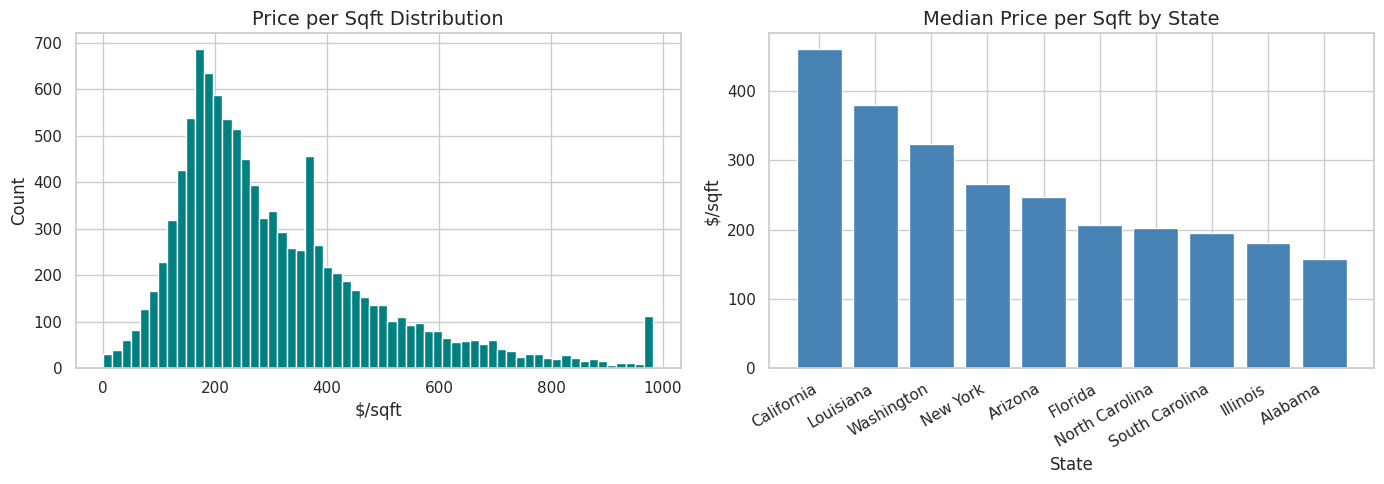

count     10586.000000
mean        352.237527
std        4278.793048
min           0.000338
25%         178.822014
50%         257.182430
75%         388.235294
max      440000.000000
Name: price_per_sqft, dtype: float64


In [49]:
# Remove zero sqft to avoid division issues
df = df[df['house_sqft'] > 0]

df['price_per_sqft'] = df['price'] / df['house_sqft']

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Distribution (clip extreme values for readability)
ppsqft = df['price_per_sqft']
ppsqft_clipped = ppsqft.clip(upper=ppsqft.quantile(0.99))

ax[0].hist(ppsqft_clipped, bins=60, color='teal', edgecolor='white')
ax[0].set_title('Price per Sqft Distribution')
ax[0].set_xlabel('$/sqft')
ax[0].set_ylabel('Count')

# State-wise median
ppsqft_state = df.groupby('state_name')['price_per_sqft'].median().sort_values(ascending=False)

ax[1].bar(ppsqft_state.index, ppsqft_state.values, color='steelblue')
ax[1].set_title('Median Price per Sqft by State')
ax[1].set_xlabel('State')
ax[1].set_ylabel('$/sqft')

plt.setp(ax[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

print(ppsqft.describe())

## 8. Multivariate Analysis

### 8.1 Correlation Heatmap

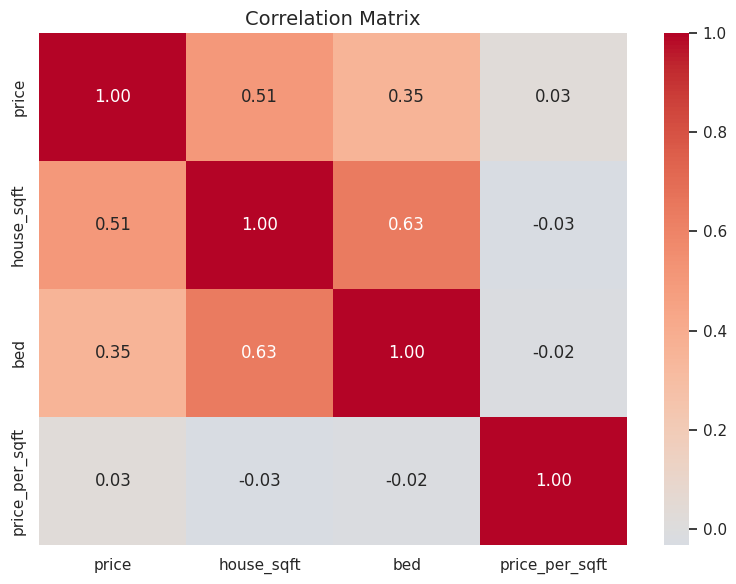

In [50]:
numeric_cols = ['price', 'house_sqft', 'bed', 'price_per_sqft']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax
)

ax.set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

### 8.2 Pair Plot (Numeric Features)

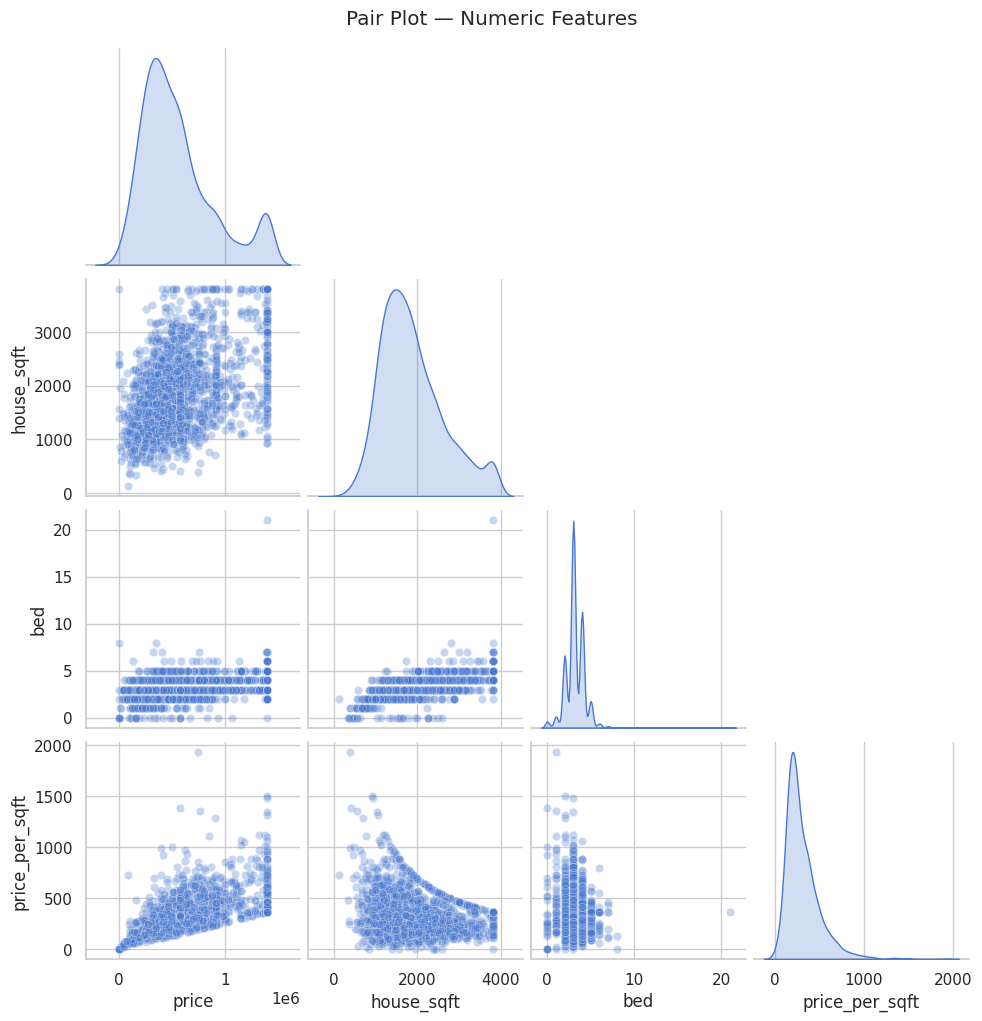

In [51]:
sample = df[numeric_cols].sample(2000, random_state=42)

sns.pairplot(
    sample,
    corner=True,
    plot_kws={'alpha': 0.3},
    diag_kind='kde'
)

plt.suptitle('Pair Plot — Numeric Features', y=1.02)
plt.show()

### 8.3 Broker vs. Unknown: Price Comparison

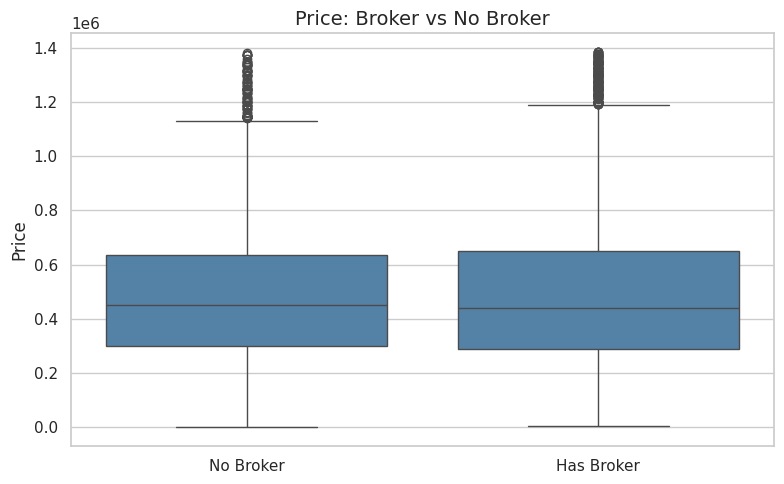

             count           mean            std     min        25%  \
has_broker                                                            
Has Broker  8444.0  553202.993188  345391.870012  2615.0  295996.25   
No Broker   2142.0  599503.766603  384974.094696     1.0  315000.00   

                      50%       75%        max  
has_broker                                      
Has Broker  463257.489788  720773.0  1387500.0  
No Broker   490000.000000  800000.0  1387500.0  


In [52]:
df['has_broker'] = df['broker'].apply(lambda x: 'No Broker' if x == 'Unknown' else 'Has Broker')

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df[df['price'] < df['price'].quantile(0.99)],
    x='has_broker',
    y='price',
    color='steelblue'
)

ax.set_title('Price: Broker vs No Broker')
ax.set_xlabel('')
ax.set_ylabel('Price')

plt.tight_layout()
plt.show()

print(df.groupby('has_broker')['price'].describe())



---

## 9. EDA Summary

**Key Findings:**

* **Price Distribution:** Price is heavily right-skewed; applying a log transformation results in a near-normal distribution, making it more suitable for regression modeling.
* **Key Driver:** House size (**sqft**) shows the strongest positive relationship with price among numeric features.
* **Geographic Variation:** States like **California** and **New York** have significantly higher median prices, while states such as **Alabama** and **Louisiana** are more affordable.
* **Property Composition:** **3-bedroom homes** are the most common listing type, indicating a concentration in mid-sized properties.
* **Outliers & Data Quality:** Extreme high-value listings (e.g., >$100M) were identified as data anomalies and removed. Remaining outliers (luxury properties) were handled using **IQR-based capping**.
* **Derived Feature Insight:** **Price per sqft** provides a normalized comparison across properties and reveals meaningful variation across states.
* **Broker Effect:** Listings associated with brokers tend to have higher median prices; however, this likely reflects property type and market segment rather than a causal relationship.
* **Feature Redundancy:** The **bathroom feature** was found to be perfectly correlated with bedrooms and was removed to avoid redundancy.
* **Temporal Analysis Limitation:** The **date feature** showed irregular listing volumes due to batch effects, making time-series analysis unreliable and thus excluded.

---

*Proceed to `04_statistical_analysis.ipynb` for correlation analysis, hypothesis testing, and regression modeling.*
